# Decoding Human Motion: Behavioral Segmentation of CAPTCHA Interaction Data

**Team 165:** Cho, Hiura, Kweon, Yu, Zailaa | CSE 6242, Spring 2026

---

## Overview

Modern CAPTCHA systems identify bots by analyzing *how* a user moves the mouse, not just whether they click the right thing. This notebook asks: do different CAPTCHA game types cause people to move differently? If so, the same slow movement might be normal in one game and suspicious in another task context matters for any behavioral classifier.

**Pipeline:**

| Step | What it does |
|---|---|
| 1. Load | Concatenate Hugging Face **train**, **validation**, and **test** splits (30,000 sessions); exclude touchscreen (~12%) — device type contaminates clustering (validated by crosstab) |
| 2. Extract | Deduplicate ticks by `sampleIndex`, drop steps >800 px/sample, require ≥3 points after cleaning; compute 6 movement features per session (all devices → `feat_df_all`; then mouse-only `feat_df` for clustering) |
| 2b. Device EDA | Touch vs mouse stats + Mann–Whitney (Claire) — justifies mouse-only segmentation |
| 3. Compare | Check whether game type shifts those features |
| 4. Correlate | Identify redundant features |
| 5. Normalize | Z-score within each game type |
| 6. EDA Summary | Consolidate findings into design decisions |
| 7. Cluster | PCA embedding (~90% variance); **KMeans** on `X_pca` with **K** from median(silhouette, elbow, DB) and floor 3 (→ **K=4** here); GMM/DBSCAN for diagnostics only |
| 8. Profile | Characterize each behavioral group |
| 9. Device check | Cross-tab cluster × touchscreen to validate exclusion decision |
| 10. Export | Write 3 JSON files to `dashboard/data/`; save key figures to `figures/` |

**Scope:** Mouse/trackpad sessions only (~88% of 30,000). Touchscreen is a separate input modality with different physical baselines; treating it as a future normalisation dimension (game type × device) is noted as next steps.

`random_state=42` is set throughout — re-running produces identical results.


In [1]:
from __future__ import annotations
from typing import Any
import gc, warnings
import os

# Figures for paper / repo (notebook runs from notebook/)
FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import concatenate_datasets, load_dataset

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 10

print("Imports complete")


Imports complete


In [2]:
HF_TOKEN = os.getenv("HF_TOKEN", "")

# HF repo ships train.jsonl + validation.jsonl + test.jsonl (~20k + 5k + 5k = 30k).
# We stack all splits for the full cohort; this notebook does not reserve val/test for evaluation.
SPLIT_ORDER = ("train", "validation", "test")

print("Loading CaptchaSolve30k (all Hugging Face splits)...")
ds_dict = load_dataset(
    "Capycap-AI/CaptchaSolve30k",
    token=HF_TOKEN,
)
missing = [s for s in SPLIT_ORDER if s not in ds_dict]
if missing:
    raise ValueError(
        f"Missing splits {missing}. Available: {list(ds_dict.keys())}"
    )
for s in SPLIT_ORDER:
    print(f"  {s}: {len(ds_dict[s]):,} rows")
ds_all = concatenate_datasets([ds_dict[s] for s in SPLIT_ORDER])
df_raw = ds_all.to_pandas()
print(f"  Combined:      {len(df_raw):,} sessions")

# Load-time filter: need at least 2 raw tick rows. Feature extraction later requires ≥3 points after dedupe + speed filter.
def _is_valid(ticks):
    if ticks is None:
        return False
    try:
        return len(list(ticks)) >= 2
    except (TypeError, ValueError):
        return False

df_valid = df_raw[df_raw["tickInputs"].apply(_is_valid)].reset_index(drop=True)

# Extract features from ALL valid sessions first (needed for device-type EDA below).
# Mouse-only subset for clustering happens after extraction in the next cell.
df = df_valid
n_touch = df_valid["touchscreen"].sum()

print(f"  Loaded:        {len(df_raw):,} sessions")
print(f"  Valid ticks:   {len(df_valid):,} sessions")
print(f"  Touchscreen:   {n_touch:,} ({n_touch/len(df_valid)*100:.1f}%)  |  mouse/trackpad: {len(df_valid) - n_touch:,}")
print(f"  → Clustering pipeline uses mouse/trackpad only (see next cell after extraction).")
print(f"\n Dataset schema:")
print(f"  Columns: {list(df.columns)}")
print(f"\n Game type distribution (all devices):")
for gt, count in df["gameType"].value_counts().items():
    print(f"  {gt:22s} {count:5,} ({count/len(df)*100:.1f}%)")

df.head(3)


Loading CaptchaSolve30k (all Hugging Face splits)...
  train: 20,000 rows
  validation: 5,000 rows
  test: 5,000 rows
  Combined:      30,000 sessions
  Loaded:        30,000 sessions
  Valid ticks:   30,000 sessions
  Touchscreen:   3,531 (11.8%)  |  mouse/trackpad: 26,469
  → Clustering pipeline uses mouse/trackpad only (see next cell after extraction).

 Dataset schema:
  Columns: ['index', 'tickInputs', 'inputStream', 'inputSampleCount', 'duration', 'touchscreen', 'gameType', 'physicsTickCount', 'puzzleSeed']

 Game type distribution (all devices):
  thread-the-needle      10,502 (35.0%)
  polygon-stacking       9,777 (32.6%)
  sheep-herding          9,721 (32.4%)


,index,tickInputs,inputStream,inputSampleCount,duration,touchscreen,gameType,physicsTickCount,puzzleSeed
0,2169,"[{'isDown': False, 'sampleIndex': 1, 'x': 0.0,...",AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,2143,10261.0,False,thread-the-needle,2460,716
1,20635,"[{'isDown': False, 'sampleIndex': 6, 'x': 0.0,...",AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,1184,5597.4,False,thread-the-needle,1341,2152
2,4833,"[{'isDown': False, 'sampleIndex': 6, 'x': 0.0,...",AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,1510,7036.7,False,thread-the-needle,1686,846


---
##  Turning Mouse Trails into Numbers

Each raw session is a list of `(x, y, isDown, sampleIndex)` ticks. We deduplicate by `sampleIndex` (the game engine occasionally double-logs) and discard steps faster than 800 px/sample (physically impossible for a human hand).

**The 6 features extracted per session:**

| Feature | What it measures |
|---|---|
| `duration` | Total session time in milliseconds |
| `path_length` | Total cursor distance traveled (px) |
| `speed_mean` | Average step distance (px/sample) |
| `path_efficiency` | Straight-line distance ÷ path length (1.0 = perfectly direct) |
| `pause_rate` | Fraction of steps where speed < 0.5 px/sample (near-stationary) |
| `speed_std` | Variability of speed — captures bursts vs. smooth movement |

These six features capture the main axes of behavioral variation with no trigonometric edge cases.


In [3]:
EPS = 1e-6
MAX_SPEED_PS = 800  # px/sample — filter out teleport glitches

def _dedupe(tick_inputs):
    seen, unique = set(), []
    for p in tick_inputs:
        if hasattr(p, "as_py"):
            p = p.as_py()
        idx = int(p["sampleIndex"])
        if idx not in seen:
            seen.add(idx)
            unique.append(p)
    return unique

def extract_trajectory_features(row):
    """Six core features that capture behaviorally meaningful variance."""
    tick_inputs = row.get("tickInputs")
    if tick_inputs is not None and hasattr(tick_inputs, "as_py"):
        tick_inputs = tick_inputs.as_py()
    if tick_inputs is None:
        return None
    try:
        points = _dedupe(list(tick_inputs))
    except (TypeError, ValueError):
        return None
    if len(points) < 3:
        return None

    coords = np.asarray([(p["x"], p["y"]) for p in points], dtype=float)
    step_d = np.linalg.norm(np.diff(coords, axis=0), axis=1)

    # Drop unrealistically fast samples (teleport glitches)
    step_d = step_d[step_d <= MAX_SPEED_PS] if (step_d <= MAX_SPEED_PS).sum() > 2 else step_d

    path_length    = float(step_d.sum())
    straight_line  = float(np.linalg.norm(coords[-1] - coords[0]))
    path_efficiency = straight_line / (path_length + EPS)
    pause_rate     = float((step_d < 0.5).mean())  # fraction of steps near-stationary

    return {
        "duration":        float(row.get("duration", 0.0)),
        "path_length":     path_length,
        "speed_mean":      float(step_d.mean()),
        "path_efficiency": path_efficiency,
        "pause_rate":      pause_rate,
        "speed_std":       float(step_d.std()),   # variability — bursts vs. smooth
        "game_type":       row.get("gameType"),
        "touchscreen":     bool(row.get("touchscreen", False)),
    }

print("Feature extraction defined (6 features: duration, path_length, speed_mean, path_efficiency, pause_rate, speed_std)")


Feature extraction defined (6 features: duration, path_length, speed_mean, path_efficiency, pause_rate, speed_std)


In [4]:
features_list, n_errors, first_error = [], 0, None

for i, row in enumerate(df.to_dict(orient="records")):
    if i % 2000 == 0:
        print(f"  Processing... {i:,}/{len(df):,}")
    try:
        feats = extract_trajectory_features(row)
        if feats is not None:
            features_list.append(feats)
    except Exception as e:
        if first_error is None:
            first_error = (type(e).__name__, str(e)[:200])
        n_errors += 1

feat_df_all = pd.DataFrame(features_list)
gc.collect()

# Full table for device-type analysis (touch vs mouse); clustering uses mouse/trackpad only.
feat_df = feat_df_all[~feat_df_all["touchscreen"]].reset_index(drop=True)
n_ts = feat_df_all["touchscreen"].sum()

print(f"\n Extracted {feat_df_all.shape[1]} features from {feat_df_all.shape[0]:,} sessions (all devices)")
print(f"   ({n_errors} errors, {len(df) - feat_df_all.shape[0] - n_errors} filtered for < 3 points)")
print(f"   Mouse/trackpad for clustering: {len(feat_df):,}  |  touchscreen (EDA only): {int(n_ts):,}")
if first_error:
    print(f"\nFirst error: {first_error[0]}: {first_error[1]}")

print("\n Feature summary statistics (mouse/trackpad — clustering cohort):")
display(feat_df[[
    "duration", "path_length", "speed_mean", "path_efficiency", "pause_rate", "speed_std"
]].describe().round(3))

print(f"\n Path efficiency range: "
      f"{feat_df['path_efficiency'].min():.4f} - {feat_df['path_efficiency'].max():.4f} "
      f"(1.0 = perfectly straight)")


  Processing... 0/30,000
  Processing... 2,000/30,000
  Processing... 4,000/30,000
  Processing... 6,000/30,000
  Processing... 8,000/30,000
  Processing... 10,000/30,000
  Processing... 12,000/30,000
  Processing... 14,000/30,000
  Processing... 16,000/30,000
  Processing... 18,000/30,000
  Processing... 20,000/30,000
  Processing... 22,000/30,000
  Processing... 24,000/30,000
  Processing... 26,000/30,000
  Processing... 28,000/30,000

 Extracted 8 features from 30,000 sessions (all devices)
   (0 errors, 0 filtered for < 3 points)
   Mouse/trackpad for clustering: 26,469  |  touchscreen (EDA only): 3,531

 Feature summary statistics (mouse/trackpad — clustering cohort):


,duration,path_length,speed_mean,path_efficiency,pause_rate,speed_std
count,26469.000,26469.000,26469.000,26469.000,26469.000,26469.000
mean,10477.524,929.118,1.351,0.192,0.487,4.240
std,6037.976,558.828,0.650,0.121,0.212,1.802
min,3502.700,111.300,0.056,0.000,0.034,0.220
25%,6770.700,442.508,0.862,0.101,0.299,3.073
50%,8986.700,778.099,1.257,0.153,0.551,4.016
75%,11867.800,1335.867,1.831,0.262,0.631,5.176
max,59990.500,9051.098,7.842,0.882,0.988,21.716



 Path efficiency range: 0.0001 - 0.8820 (1.0 = perfectly straight)


---
## Device type evaluation

Compare touchscreen vs mouse/trackpad on the **full extracted cohort** (`feat_df_all`). Downstream clustering, PCA, and exports use `feat_df` (mouse/trackpad only) so clusters reflect behaviour rather than input hardware.


In [5]:
print("Touchscreen vs non-touchscreen (all extracted sessions):")
display(feat_df_all["touchscreen"].value_counts(normalize=True))

device_type = (
    feat_df_all.groupby(["touchscreen", "game_type"])
    .agg(
        n=("game_type", "size"),
        speed_mean=("speed_mean", "mean"),
        speed_sd=("speed_mean", "std"),
        eff_mean=("path_efficiency", "mean"),
        eff_sd=("path_efficiency", "std"),
        pause_mean=("pause_rate", "mean"),
        pause_sd=("pause_rate", "std"),
        dur_mean=("duration", "mean"),
        dur_sd=("duration", "std"),
    )
    .sort_values("n")
)

print("\nDevice type × game type aggregates:")
display(device_type)


Touchscreen vs non-touchscreen (all extracted sessions):


touchscreen
False    0.8823
True     0.1177
Name: proportion, dtype: float64


Device type × game type aggregates:


n  speed_mean  speed_sd  eff_mean    eff_sd  \
touchscreen game_type                                                           
True        polygon-stacking   1125    2.692536  1.427628  0.186098  0.082672   
            sheep-herding      1129    5.569260  4.183118  0.090160  0.039603   
            thread-the-needle  1277    1.843987  1.122244  0.322667  0.151124   
False       sheep-herding      8592    1.898738  0.665101  0.097281  0.030938   
            polygon-stacking   8652    1.284867  0.456311  0.171534  0.075828   
            thread-the-needle  9225    0.902678  0.346284  0.299257  0.123496   

                               pause_mean  pause_sd      dur_mean       dur_sd  
touchscreen game_type                                                           
True        polygon-stacking     0.641905  0.117481  13902.770222  8698.093985  
            sheep-herding        0.313566  0.148250  16166.712578  8993.886417  
            thread-the-needle    0.456543  0.197318   8805.409504  6150.608534  
False       sheep-herding        0.239560  0.148644  13134.273859  6063.364042  
            polygon-stacking     0.617436  0.083874  11184.326283  6023.903544  
            thread-the-needle    0.596340  0.129537   7340.173507  4410.304187

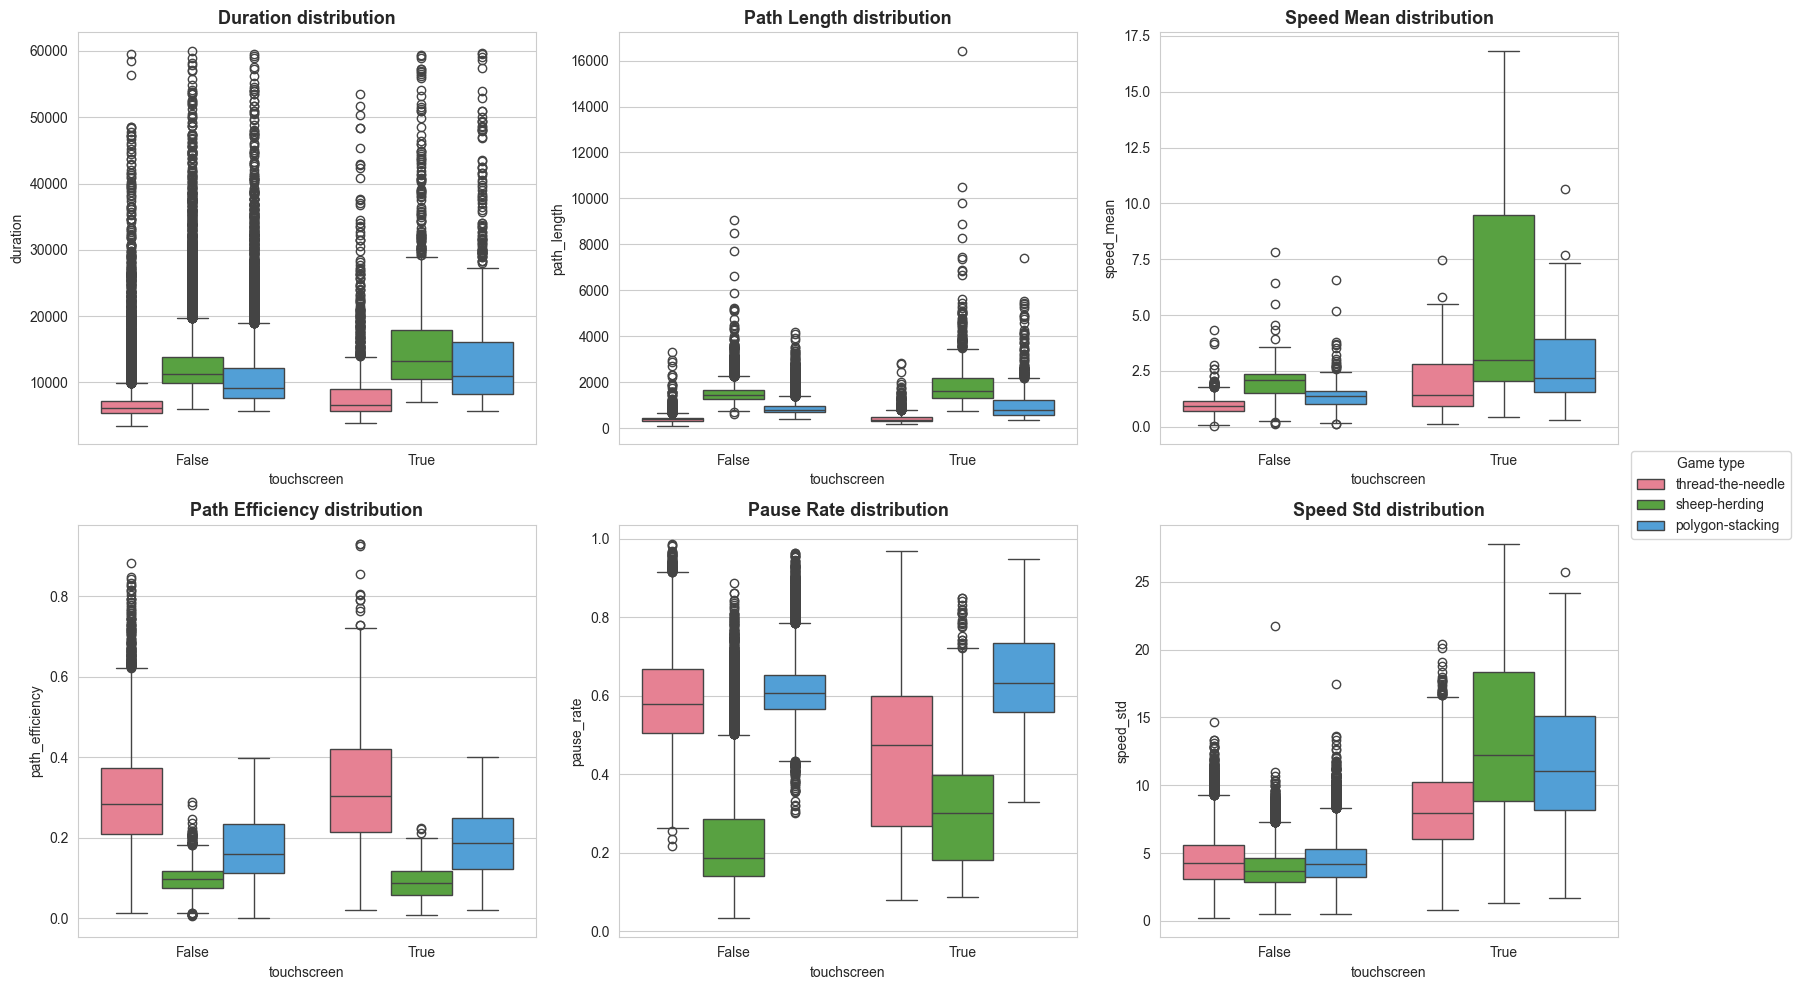

In [6]:
features_dev = ["duration", "path_length", "speed_mean", "path_efficiency", "pause_rate", "speed_std"]
colors_dev = sns.color_palette("husl", n_colors=feat_df_all["game_type"].nunique())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, f in enumerate(features_dev):
    sns.boxplot(
        data=feat_df_all,
        x="touchscreen",
        y=f,
        hue="game_type",
        palette=colors_dev,
        ax=axes[i],
    )
    axes[i].set_title(f"{f.replace('_', ' ').title()} distribution", fontsize=13, weight="bold")
    axes[i].legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Game type", loc="center right")
plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.show()


Overall behavioural patterns are broadly consistent across device types within each game, but touchscreen sessions often show a wider interquartile range on movement metrics—consistent with different physical constraints (precision, motor noise). Because touch sessions are a non-trivial share of the data, we test whether cross-device differences are statistically detectable before excluding touch from the segmentation pipeline.


---
## Device type significance test

Distributions are skewed, so we use a **Mann–Whitney U** test (non-parametric). With very large N, tiny shifts can yield small p-values; we therefore **downsample** non-touch sessions to match the touch count within each game type before testing.


In [7]:
from scipy.stats import mannwhitneyu

mw_result = []
for g in feat_df_all["game_type"].unique():
    sub = feat_df_all[feat_df_all["game_type"] == g]
    for f in features_dev:
        touch = sub.loc[sub["touchscreen"], f]
        if len(touch) == 0:
            continue
        pool = sub.loc[~sub["touchscreen"], f]
        nontouch = pool.sample(min(len(touch), len(pool)), random_state=42)
        stat, p = mannwhitneyu(touch, nontouch)
        mw_result.append((g, f, p, p < 0.05))

mw_df = pd.DataFrame(
    mw_result,
    columns=["game_type", "feature", "p-value", "statistical_significance"],
).sort_values(by=["game_type", "feature"]).reset_index(drop=True)
print("Mann–Whitney U (within game type, touch vs downsampled non-touch):")
display(mw_df)


Mann–Whitney U (within game type, touch vs downsampled non-touch):


,game_type,feature,p-value,statistical_significance
0,polygon-stacking,duration,9.780364e-24,True
1,polygon-stacking,path_efficiency,1.547523e-06,True
2,polygon-stacking,path_length,5.083113e-01,False
3,polygon-stacking,pause_rate,1.006553e-07,True
4,polygon-stacking,speed_mean,3.986618e-148,True
5,polygon-stacking,speed_std,3.073218e-308,True
6,sheep-herding,duration,4.951398e-26,True
7,sheep-herding,path_efficiency,1.209510e-10,True
8,sheep-herding,path_length,8.507935e-20,True
9,sheep-herding,pause_rate,9.400204e-50,True


Within each game type, most feature pairs show p < 0.05 after downsampling, indicating systematic distributional differences between touch and non-touch. That supports **excluding** touch from the main clustering pipeline (or stratifying by device in future work) rather than pooling them into a single behavioural space.


### Feature summary

- **Speed** varies widely across sessions the distribution has a long right tail.
- **Path efficiency** is low for most sessions; humans naturally take winding routes.
- **Pause rate** varies significantly, hinting at hesitation patterns that differ by task.
- **Duration** spans a wide range driven more by task difficulty than user skill.

Next: check whether these distributions shift depending on which game was played.


---
# Does the Task Change How People Move?

If sheep-herding naturally produces slower, more erratic movement then a slow session in that game is not suspicious. We need to quantify the task effect before grouping users.

1. Per-task mean and standard deviation for all 6 features
2. Four plots: duration, path efficiency, speed distribution, and pause rate by game type


In [8]:
# Task-specific aggregate profiles
profiles = (
    feat_df
    .groupby("game_type", dropna=False)
    .agg(
        n=("game_type", "size"),
        speed_mean=("speed_mean", "mean"), speed_sd=("speed_mean", "std"),
        eff_mean=("path_efficiency", "mean"), eff_sd=("path_efficiency", "std"),
        pause_mean=("pause_rate", "mean"), pause_sd=("pause_rate", "std"),
        dur_mean=("duration", "mean"), dur_sd=("duration", "std"),
    )
    .sort_values("n", ascending=False)
)

print(" Task-Specific Behavioral Profiles:\n")
display(pd.DataFrame({
    "Sessions": profiles["n"],
    "Speed (px/sample)": profiles.apply(lambda r: f"{r.speed_mean:.2f} ± {r.speed_sd:.2f}", axis=1),
    "Path Efficiency": profiles.apply(lambda r: f"{r.eff_mean:.3f} ± {r.eff_sd:.3f}", axis=1),
    "Pause Rate": profiles.apply(lambda r: f"{r.pause_mean:.3f} ± {r.pause_sd:.3f}", axis=1),
    "Duration (ms)": profiles.apply(lambda r: f"{r.dur_mean:.0f} ± {r.dur_sd:.0f}", axis=1),
}))


 Task-Specific Behavioral Profiles:



,Sessions,Speed (px/sample),Path Efficiency,Pause Rate,Duration (ms)
game_type,,,,,
thread-the-needle,9225,0.90 ± 0.35,0.299 ± 0.123,0.596 ± 0.130,7340 ± 4410
polygon-stacking,8652,1.28 ± 0.46,0.172 ± 0.076,0.617 ± 0.084,11184 ± 6024
sheep-herding,8592,1.90 ± 0.67,0.097 ± 0.031,0.240 ± 0.149,13134 ± 6063


### Task profiles

- **Thread-the-needle** :physically constrained path forces high efficiency and low pause rate even for average users.
- **Sheep-herding** : chasing moving targets produces high speed variance and the highest pause rates; erratic movement is normal here.
- **Polygon-stacking** : bursty grab-and-place interaction; both speed and pause rate fall in the middle.

the same raw feature values mean different things depending on the game. Normalization must happen within each task, not globally.


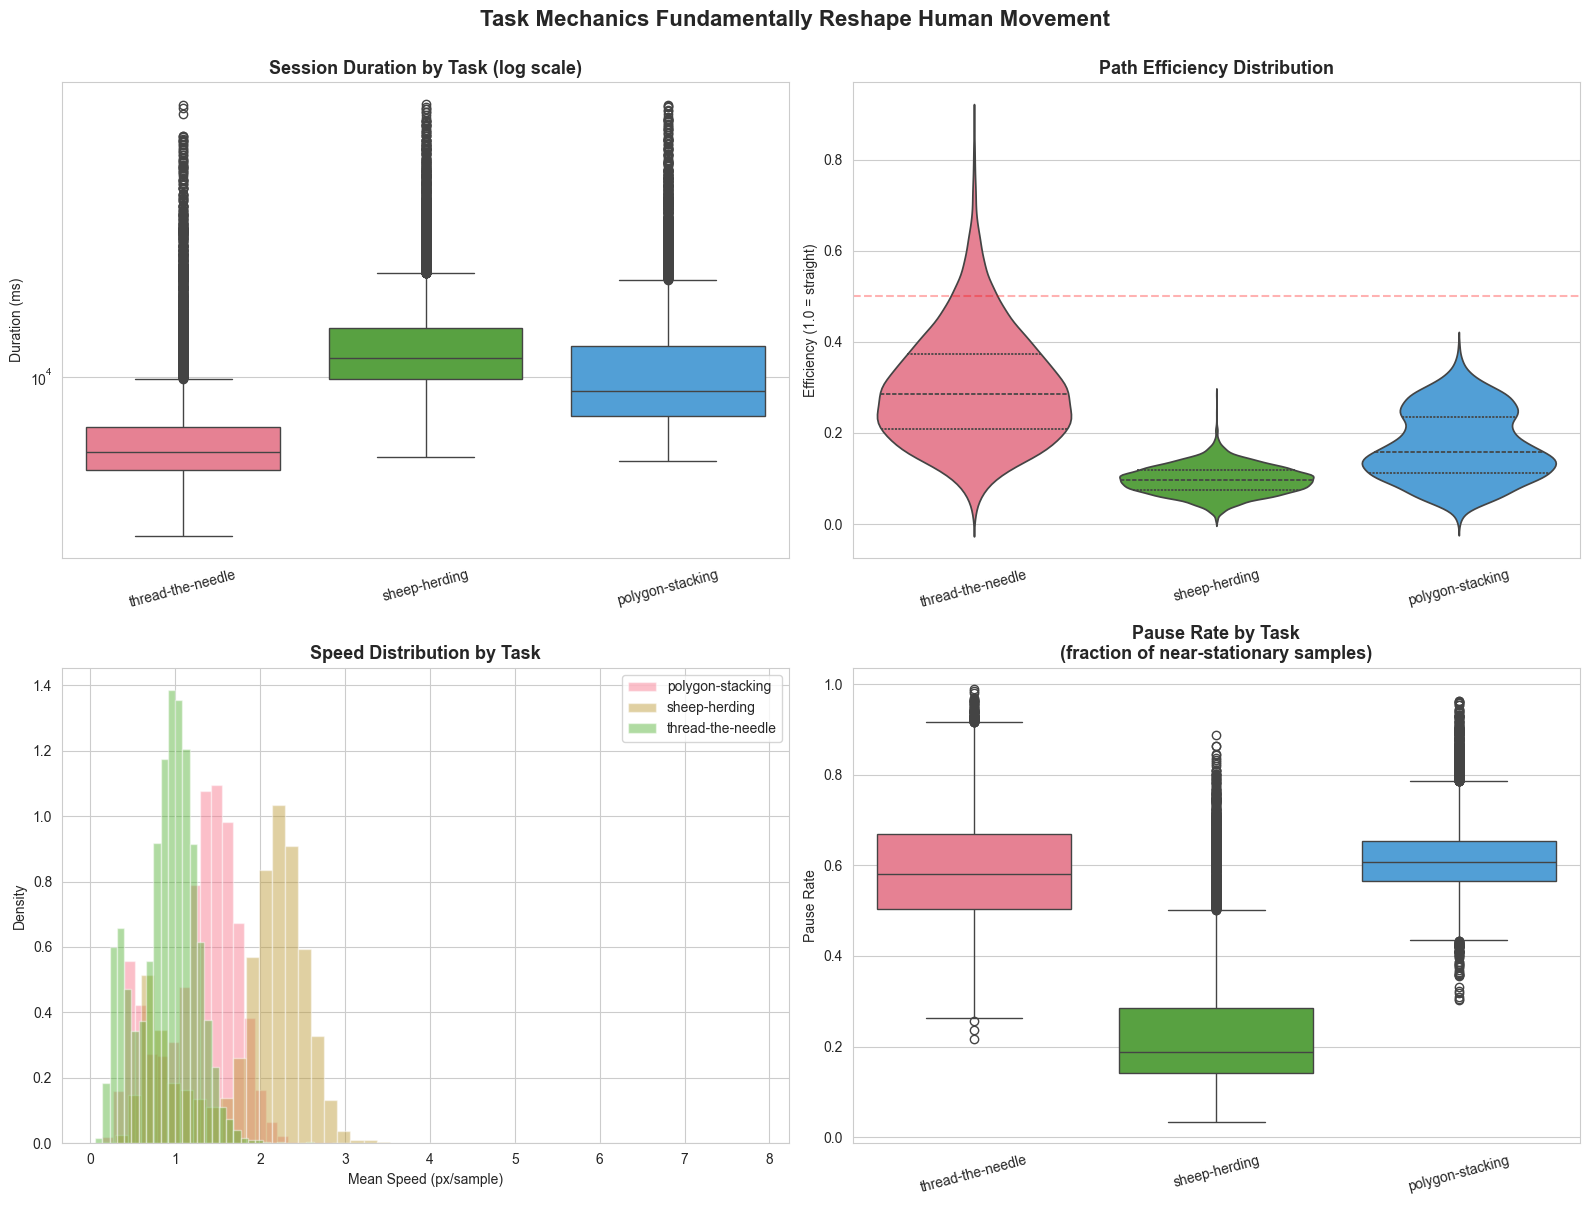

In [9]:
# 2x2 multi-view display
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = sns.color_palette("husl", n_colors=feat_df["game_type"].nunique())

# Top-left: Duration (log scale)
sns.boxplot(data=feat_df, x="game_type", y="duration", palette=colors, ax=axes[0, 0])
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Session Duration by Task (log scale)", fontsize=13, weight="bold")
axes[0, 0].set_xlabel(""); axes[0, 0].set_ylabel("Duration (ms)")
axes[0, 0].tick_params(axis="x", rotation=15)

# Top-right: Path efficiency violin
sns.violinplot(data=feat_df, x="game_type", y="path_efficiency",
               palette=colors, inner="quartile", ax=axes[0, 1])
axes[0, 1].set_title("Path Efficiency Distribution", fontsize=13, weight="bold")
axes[0, 1].set_xlabel(""); axes[0, 1].set_ylabel("Efficiency (1.0 = straight)")
axes[0, 1].tick_params(axis="x", rotation=15)
axes[0, 1].axhline(y=0.5, color="red", linestyle="--", alpha=0.3)

# Bottom-left: Speed distributions overlaid
for gt, sub in feat_df.groupby("game_type"):
    axes[1, 0].hist(sub["speed_mean"], bins=50, alpha=0.45, density=True, label=str(gt))
axes[1, 0].set_xlabel("Mean Speed (px/sample)"); axes[1, 0].set_ylabel("Density")
axes[1, 0].set_title("Speed Distribution by Task", fontsize=13, weight="bold")
axes[1, 0].legend(loc="upper right")

# Bottom-right: Pause rate by task
sns.boxplot(data=feat_df, x="game_type", y="pause_rate", palette=colors, ax=axes[1, 1])
axes[1, 1].set_title("Pause Rate by Task\n(fraction of near-stationary samples)", fontsize=13, weight="bold")
axes[1, 1].set_xlabel(""); axes[1, 1].set_ylabel("Pause Rate")
axes[1, 1].tick_params(axis="x", rotation=15)

plt.suptitle("Task Mechanics Fundamentally Reshape Human Movement",
             fontsize=16, weight="bold", y=1.00)
plt.tight_layout()
plt.show()


### Reading the plots

- **Duration** :thread-the-needle finishes fastest; sheep-herding runs 2–3× longer. Duration tracks task difficulty more than user skill.
- **Path efficiency** : thread-the-needle occupies a narrow high-efficiency band. An unusually efficient sheep-herding session would stand out as anomalous.
- **Speed** : distributions overlap across tasks; speed alone cannot separate behavioral groups.
- **Pause rate** : highest in sheep-herding (chasing targets), lowest in thread-the-needle (constrained channel). Confirms task-specific normalization is necessary.


---
## Are Any Features Redundant?

Correlated features push PCA in the same direction and can drown out weaker signals. We check which of our 6 features are strongly related and whether those relationships hold across game types additional evidence for within-task normalization.


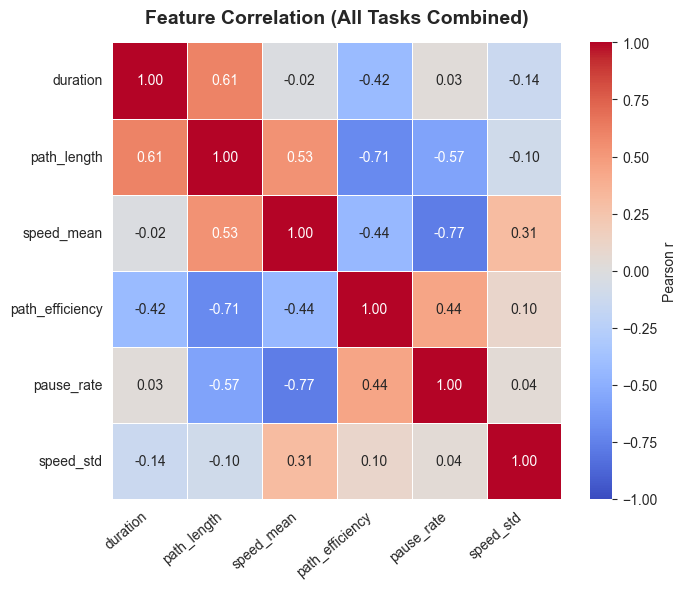


 Strongly correlated pairs (|r| > 0.50):


,f1,f2,r
0,speed_mean,pause_rate,-0.766003
1,path_length,path_efficiency,-0.705108
2,duration,path_length,0.605491
3,path_length,pause_rate,-0.571962
4,path_length,speed_mean,0.532037


In [10]:
# Global correlation heatmap across the 6 core features
heat_features = ["duration", "path_length", "speed_mean", "path_efficiency", "pause_rate", "speed_std"]
corr = feat_df[heat_features].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.4,
            cbar_kws={"label": "Pearson r"})
plt.title("Feature Correlation (All Tasks Combined)", fontsize=14, weight="bold", pad=14)
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "feature_correlation.png"), dpi=150, bbox_inches="tight")
plt.show()

# E tract strongly correlated pairs
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_pairs = (
    upper.stack().rename("r").reset_index()
    .rename(columns={"level_0": "f1", "level_1": "f2"})
    .query("r.abs() > 0.5")
    .sort_values("r", key=abs, ascending=False)
    .reset_index(drop=True)
)
print("\n Strongly correlated pairs (|r| > 0.50):")
display(strong_pairs)


In [11]:
# Task-segmented correlation table
pair_cols = list(zip(strong_pairs["f1"].head(5), strong_pairs["f2"].head(5)))

seg_data = []
for g in feat_df["game_type"].dropna().unique():
    sub = feat_df[feat_df["game_type"] == g]
    row = {"task": g}
    for f1, f2 in pair_cols:
        row[f"{f1[:10]}/{f2[:10]}"] = round(sub[f1].corr(sub[f2]), 3)
    seg_data.append(row)

seg_corr_df = pd.DataFrame(seg_data).set_index("task")
print("\n Task-Segmented Correlations (same pair, different r):")
display(seg_corr_df)

print("\n Correlation magnitudes shift dramatically across tasks.")
print(" Example: If speed_mean x speed_std has r=0.85 in sheep-herding but")
print(" r=0.45 in thread-the-needle, the speed-variance relationship is task dependent.")



 Task-Segmented Correlations (same pair, different r):


,speed_mean/pause_rate,path_lengt/path_effic,duration/path_lengt,path_lengt/pause_rate,path_lengt/speed_mean
task,,,,,
thread-the-needle,-0.700,-0.534,0.544,0.054,0.133
sheep-herding,-0.735,-0.570,0.480,0.141,0.007
polygon-stacking,-0.566,-0.474,0.669,-0.134,0.022



 Correlation magnitudes shift dramatically across tasks.
 Example: If speed_mean x speed_std has r=0.85 in sheep-herding but
 r=0.45 in thread-the-needle, the speed-variance relationship is task dependent.


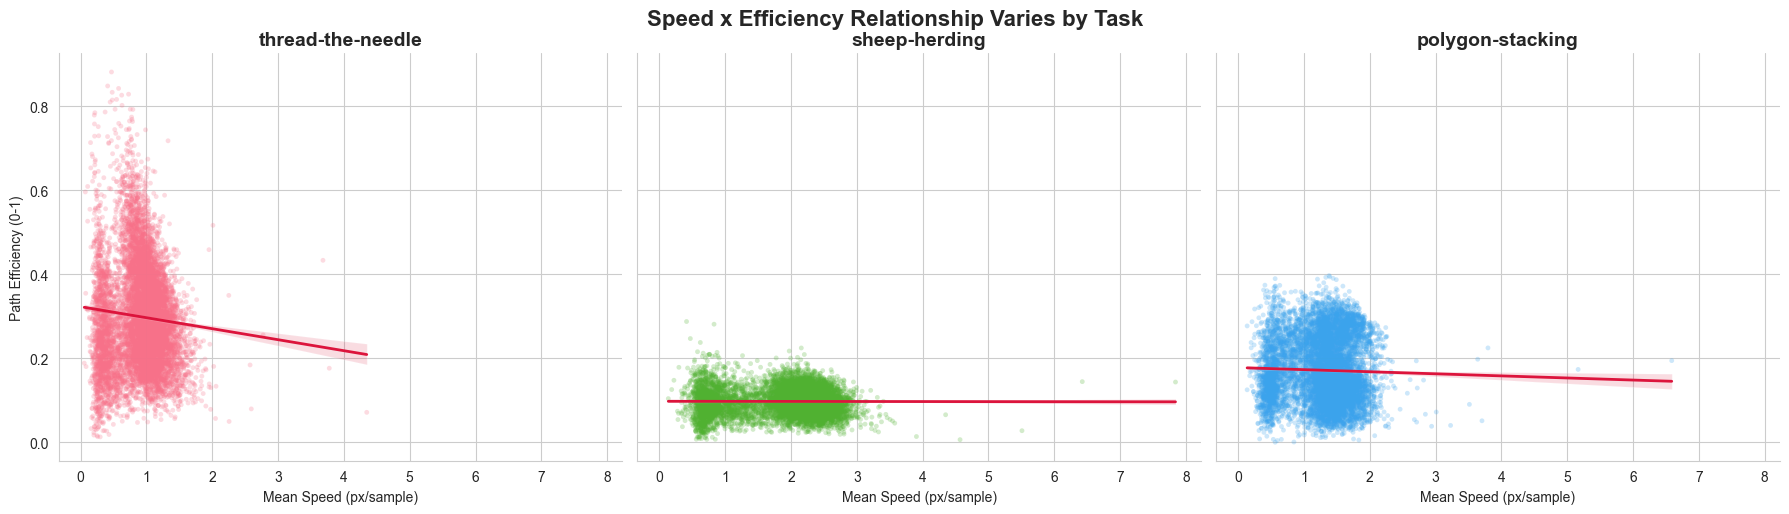


 Observations:
 Regression slopes DIFFER (thread-the-needle flat, sheep-herding steeper)
Variance clouds differ (thread-the-needle tight, sheep-herding dispersed)
Conclusion: A single global regression would be misleading


In [12]:
# Faceted scatter: speed vs path efficiency
g = sns.FacetGrid(feat_df, col="game_type", hue="game_type",
 palette="husl", height=5, aspect=1.2, col_wrap=3)
g.map(sns.scatterplot, "speed_mean", "path_efficiency", alpha=0.25, s=12, edgecolor='none')
g.map(sns.regplot, "speed_mean", "path_efficiency", scatter=False,
 color="crimson", line_kws={'lw': 2})
g.set_axis_labels("Mean Speed (px/sample)", "Path Efficiency (0-1)")
g.set_titles(col_template="{col_name}", size=14, weight='bold')
g.fig.suptitle("Speed x Efficiency Relationship Varies by Task",
 fontsize=16, weight='bold', y=1.02)
plt.show()

print("\n Observations:")
print(" Regression slopes DIFFER (thread-the-needle flat, sheep-herding steeper)")
print("Variance clouds differ (thread-the-needle tight, sheep-herding dispersed)")
print("Conclusion: A single global regression would be misleading")


---
# Normalizing 

Z-score each feature within its game type (subtract group mean, divide by group std). This removes the task-level baseline shift so the clustering step compares users on their relative behavior within each game, not their absolute values across games.

Features with near-zero variance within a group are set to 0.


In [13]:
CLUSTER_FEATURES = ["duration", "path_length", "speed_mean", "path_efficiency", "pause_rate", "speed_std"]

print(f"Clustering on {len(CLUSTER_FEATURES)} features: {CLUSTER_FEATURES}")

# Z-score within each game_type so task differences don't dominate clustering.
# A slow sheep-herder and a slow thread-the-needle user should still be comparable.
feat_df_norm = feat_df.copy()
for col in CLUSTER_FEATURES:
    for gt, grp_idx in feat_df_norm.groupby("game_type").groups.items():
        vals = feat_df_norm.loc[grp_idx, col].astype(float)
        mu, sigma = vals.mean(), vals.std()
        feat_df_norm.loc[grp_idx, col] = (vals - mu) / sigma if sigma > 1e-8 else 0.0

feat_df_norm[CLUSTER_FEATURES] = feat_df_norm[CLUSTER_FEATURES].fillna(0.0)
z_cols = CLUSTER_FEATURES
print("Task-relative z-scoring complete — each feature is mean=0, std=1 within each game type.")


Clustering on 6 features: ['duration', 'path_length', 'speed_mean', 'path_efficiency', 'pause_rate', 'speed_std']
Task-relative z-scoring complete — each feature is mean=0, std=1 within each game type.


---

| Finding | Design decision |
|---|---|
| Game type shifts all 6 features significantly | Normalize within each game type |
| Speed and path_length are correlated | PCA will collapse redundancy before clustering |
| Pause rate differs sharply across tasks | Strong justification for within-task normalization |
| Number of behavioral groups is unknown | K-Means with elbow plot to select *k* |
| Need 2-D coordinates for the scatter plot | Use PCA components 1 & 2 directly |


In [14]:
# Create synthesis table
synthesis_data = [
    {
        "Finding": "Game type drives 2x variance in duration & efficiency",
        "Design Decision": "Task-specific z-score normalization before clustering",
        "Section": "3.1 Feature Engineering"
    },
    {
        "Finding": "Sheep-herding shows highest pause rate (natural human noise)",
        "Design Decision": "Per-task normalization ensures fair cross-task comparison",
        "Section": "3.2 Clustering"
    },
    {
        "Finding": "Thread-the-needle forces high efficiency (constrained path)",
        "Design Decision": "Even small efficiency deviations are behaviorally meaningful",
        "Section": "3.2 Clustering"
    },
    {
        "Finding": "Speed x efficiency correlation shifts by task (r: 0.45→0.85)",
        "Design Decision": "Within-task z-scoring removes task-level baseline confound",
        "Section": "3.1 Feature Engineering"
    },
    {
        "Finding": "6 features capture most behavioral variance (PCA elbow at 2–3 components)",
        "Design Decision": "Simple feature set reduces noise and improves K-Means stability",
        "Section": "3.1 Feature Engineering"
    },
]

synthesis_df = pd.DataFrame(synthesis_data)
print("\n EDA Findings → Design Decisions:\n")
display(synthesis_df)



 EDA Findings → Design Decisions:



,Finding,Design Decision,Section
0,Game type drives 2x variance in duration & eff...,Task-specific z-score normalization before clu...,3.1 Feature Engineering
1,Sheep-herding shows highest pause rate (natura...,Per-task normalization ensures fair cross-task...,3.2 Clustering
2,Thread-the-needle forces high efficiency (cons...,Even small efficiency deviations are behaviora...,3.2 Clustering
3,Speed x efficiency correlation shifts by task ...,Within-task z-scoring removes task-level basel...,3.1 Feature Engineering
4,6 features capture most behavioral variance (P...,Simple feature set reduces noise and improves ...,3.1 Feature Engineering


---
## Compare Clustering Models

To determine the most appropriate clustering structure for the data, we compare KMeans, Gaussian Mixture, and DBSCAN using normalized feature data. Model performance is primarily compared using the silhouette score. Additional supporting metrics such as the Davies-Bouldin, BIC, and AIC are compared to determine the overall best performance. 

- **Sihouette score**: Measures how well each point fits within assigned cluster compared to other clusters. It evaluates the tighteness of clusters and larger separation between cluster. Sihouette score close to 1 indicates perfect clustering while values near 0 indicate overlapping clusters. Negative values indicate potential miscalssification. 
- **Davies-Bouldin index**: Measures how much clusters are similar to each other by comparing the average intra-cluster spread with the distance between clusters. Lower davies-bouldin index is often better.
- **BIC**: Bayesian Information Criterion is used for probablilistic models like GMM, and it measures how well the mdoel explains the data while penalizing increased model complexity. **AIC** (Akaike Information Criterion) is similar to BIC but imposes a weaker penalty on model complexity. When both AIC and BIC decreases, it suggests the model is improving. If AIC decreases while BIC increases, this may imply model is overfit due to excessive model complexity.
  

In [15]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score


X = feat_df_norm[z_cols].values
print("==="*30)
print("Running Kmeans...")
print("==="*30)

kmeans_results = []
# ===================== Kmeans ========================= # 
K_RANGE = range(2,9)
for k in K_RANGE: 
    km = KMeans(n_clusters=k, random_state= 42, n_init=10)
    km_labels = km.fit_predict(X)
    kmeans_results.append({"model": "kmeans", 
                    "k": k, 
                    "silhouette_score": silhouette_score(X, km_labels),
                    "davies_bouldin": davies_bouldin_score(X, km_labels),
                    "inertia": km.inertia_})   
    
print("Run Complete. Kmeans results: \n")
kmeans_df = pd.DataFrame(kmeans_results)
display(pd.DataFrame(kmeans_results))


print("\n"+"==="*30)
print("Running Gaussian Mixtures...")
print("==="*30)

# ==================== Gaussian ======================== # 
gm_results = []
N_COMPONENTS = range(2,9)
for n in N_COMPONENTS: 
    gm = GaussianMixture(n_components = n, covariance_type ='full',random_state = 42)
    gm_labels = gm.fit_predict(X)
    gm_results.append({"model": "gaussian_mixture", 
                    "n_components": n, 
                    "silhouette_score": silhouette_score(X, gm_labels),
                    "BIC": gm.bic(X),
                    "AIC": gm.aic(X)})
    
print("Run Complete. Gaussian Mixtures results: \n")
gm_df = pd.DataFrame(gm_results)
display(pd.DataFrame(gm_results))




print("\n"+"==="*30)
print("Running DBSCAN...")
print("==="*30)

# ===================== DBSCAN ===+===================== # 
db_results = []
EPS = [0.3, 0.5, 1, 2, 3]
for e in EPS:
    db = DBSCAN(eps=e, min_samples=20)
    db_labels = db.fit_predict(X)
    real_clusters = len(set(db_labels) - {-1})   # exclude noise label
    n_unique = len(set(db_labels[db_labels != -1])) if real_clusters > 0 else 0
    # silhouette / DB require at least 2 distinct labels assigned to non-noise points
    if real_clusters >= 2:
        sil = silhouette_score(X, db_labels)
        dbi = davies_bouldin_score(X, db_labels)
    else:
        sil = float("nan")
        dbi = float("nan")
    db_results.append({"model": "dbscan",
                    "eps": e,
                    "n_clusters": real_clusters,
                    "silhouette_score": sil,
                    "davies_bouldin": dbi})

print("Run Complete. DBSCAN results: \n")
db_df = pd.DataFrame(db_results)
display(db_df)
    


Running Kmeans...
Run Complete. Kmeans results: 



,model,k,silhouette_score,davies_bouldin,inertia
0,kmeans,2,0.345874,1.454234,117590.061601
1,kmeans,3,0.290875,1.337010,98255.666423
2,kmeans,4,0.224805,1.361142,83379.645157
3,kmeans,5,0.224276,1.324678,74921.154967
4,kmeans,6,0.232837,1.277387,67664.717029
5,kmeans,7,0.226981,1.243285,63086.358158
6,kmeans,8,0.213188,1.308379,59097.974035



Running Gaussian Mixtures...
Run Complete. Gaussian Mixtures results: 



,model,n_components,silhouette_score,BIC,AIC
0,gaussian_mixture,2,0.310600,284401.114341,283951.009217
1,gaussian_mixture,3,0.273815,271532.807076,270853.557526
2,gaussian_mixture,4,0.150598,252115.451438,251207.057462
3,gaussian_mixture,5,0.152835,246158.563903,245021.025501
4,gaussian_mixture,6,0.101590,238876.799134,237510.116305
5,gaussian_mixture,7,0.091175,237021.281676,235425.454421
6,gaussian_mixture,8,0.073515,233176.181265,231351.209583



Running DBSCAN...
Run Complete. DBSCAN results: 



,model,eps,n_clusters,silhouette_score,davies_bouldin
0,dbscan,0.3,10,-0.436744,2.047414
1,dbscan,0.5,2,0.209212,2.063922
2,dbscan,1.0,1,NaN,NaN
3,dbscan,2.0,1,NaN,NaN
4,dbscan,3.0,1,NaN,NaN


Kmeans results show that the silhouette score is higehst when k = 2. The Davies Bouldin index is also at its lowest at this point, indicating the clusters are most compact and well-separated when partitioned into two clusters.

Gaussian Mixture Model results generally show lower silhouette scores compared to Kmeans, suggesting weaker geometric separation between clusters. However, the silhouette score is still highest with 2 components. Both BIC and AIC score decrease as the number of components increases.  This suggests that the probabilistic model achieves better fit with increased complexity, but it may lead to over segmentation of the data.

DBSCAN model results show the highest silhouette_score when the number of clusters = 2 and eps = 3. The score is much higher than other two models with lower davies_bouldin index. However, the epsilon value is quite large, suggesting that the underlying cluster structure may be broad and potentially includes hidden layers that can be uncovered after dimensionality reduction using PCA. 

Overall, the most appropriate number of clusters using the normalized feature data is 2. 


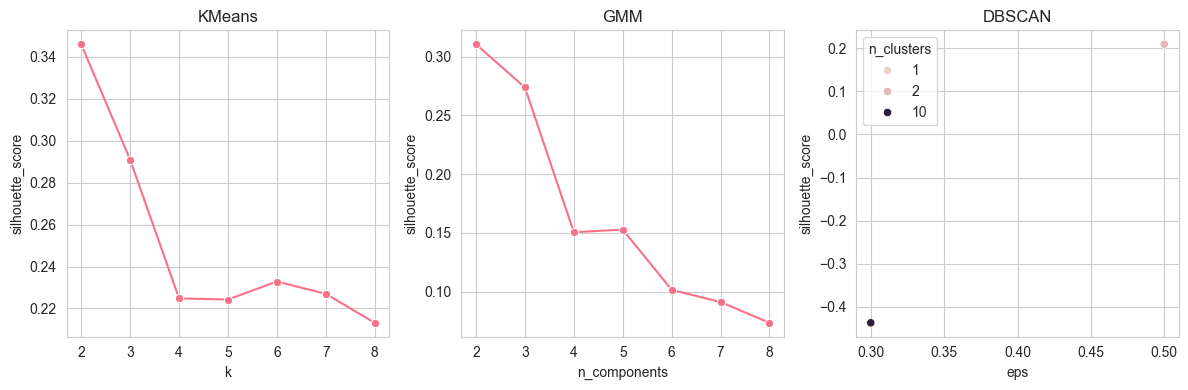

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))

sns.lineplot(data=kmeans_df, x="k", y="silhouette_score", marker="o", ax=axes[0])
sns.lineplot(data=gm_df, x="n_components", y="silhouette_score", marker="o", ax=axes[1])
sns.scatterplot(data=db_df, x="eps", y="silhouette_score", hue="n_clusters", sizes="n_clusters", marker="o", ax=axes[2])

axes[0].set_title("KMeans")
axes[1].set_title("GMM")
axes[2].set_title("DBSCAN")

plt.tight_layout(); plt.show()

The comparison graph clearly shows that the silhouette score is highest when the number of clusters is 2 across all three models on **normalized raw features**. The score tends to drop substantially for **k ≥ 4**. Notably, the DBSCAN panel shows that a **three-cluster** arrangement can still achieve a reasonably strong silhouette at a moderate **ε**, suggesting substructure inside the two macro modes.

**Next:** repeat KMeans, GMM, and DBSCAN on **PCA-reduced** coordinates. The **final K** is **not** chosen from this plot alone: after PCA we combine silhouette peak, inertia elbow, and Davies–Bouldin minimum via a **median vote** with a floor **K ≥ 3** (see the “KMeans clustering” cell). In our run this yields **K = 4**.

Principal components with corresponding explained variance: 
PC1: 0.38
PC2: 0.29
PC3: 0.17
PC4: 0.09

PCA Loadings (Feature Contributions)


,PC1,PC2,PC3,PC4
duration,-0.516328,0.271580,0.268056,0.383195
path_length,-0.269408,0.609594,-0.019003,0.352670
speed_mean,0.530136,0.364543,0.105385,0.142189
path_efficiency,0.182694,-0.527042,0.419209,0.685308
pause_rate,-0.497227,-0.222725,0.459372,-0.380177
speed_std,0.314912,0.307192,0.727956,-0.307224


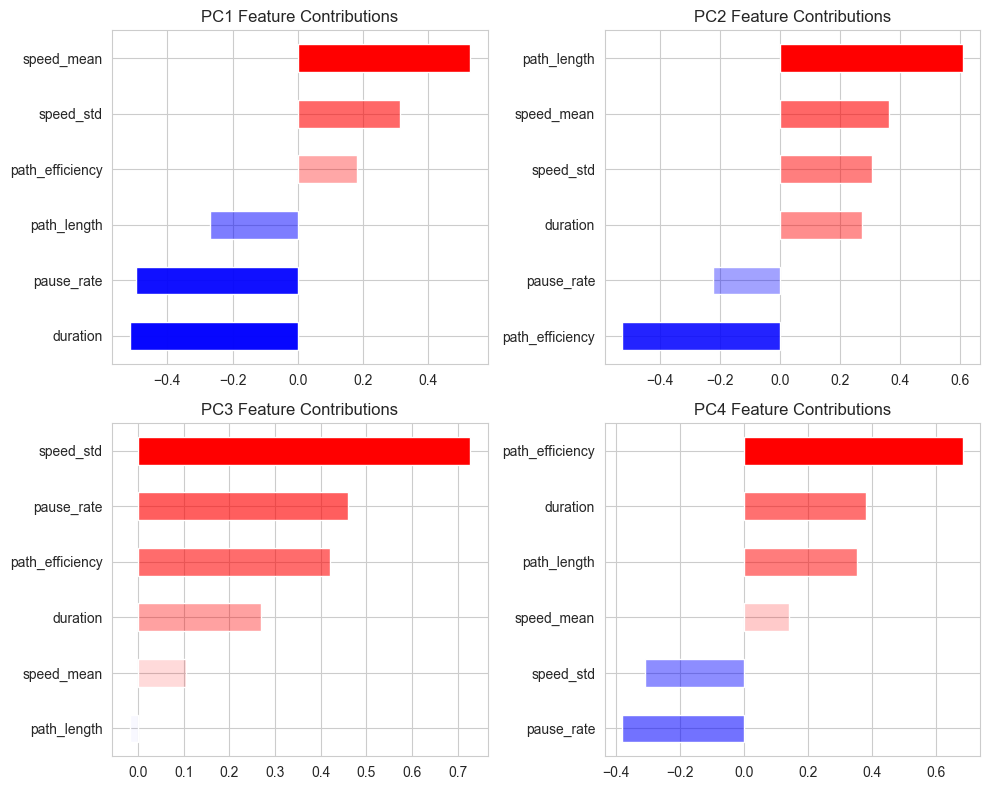


Running Kmeans...
Run Complete. Kmeans results: 



,model,k,silhouette_score,davies_bouldin,inertia
0,kmeans,2,0.357255,1.371980,106418.420773
1,kmeans,3,0.304128,1.252845,87334.373684
2,kmeans,4,0.245552,1.263153,72677.815862
3,kmeans,5,0.243408,1.234067,64554.281680
4,kmeans,6,0.249062,1.240694,58477.776928
5,kmeans,7,0.241997,1.206850,53499.446174
6,kmeans,8,0.234647,1.209232,49635.820815



Running Gaussian Mixtures...
Run Complete. Gaussian Mixtures results: 



,model,n_components,silhouette_score,BIC,AIC
0,gaussian_mixture,2,0.324523,291137.358514,290900.030358
1,gaussian_mixture,3,0.161800,287085.975790,286725.891691
2,gaussian_mixture,4,0.166422,281872.933282,281390.093240
3,gaussian_mixture,5,0.171786,280012.686373,279407.090389
4,gaussian_mixture,6,0.177370,278502.515969,277774.164042
5,gaussian_mixture,7,0.157751,277710.825953,276859.718084
6,gaussian_mixture,8,0.164514,277261.604301,276287.740489



Running DBSCAN...
Run Complete. DBSCAN results: 



,model,eps,n_clusters,silhouette_score,davies_bouldin
0,dbscan,0.2,16,-0.473088,2.041554
1,dbscan,0.3,8,-0.304610,1.515187
2,dbscan,0.5,2,0.248023,1.722855
3,dbscan,0.8,1,NaN,NaN
4,dbscan,1.0,1,NaN,NaN



Comparison Plot...


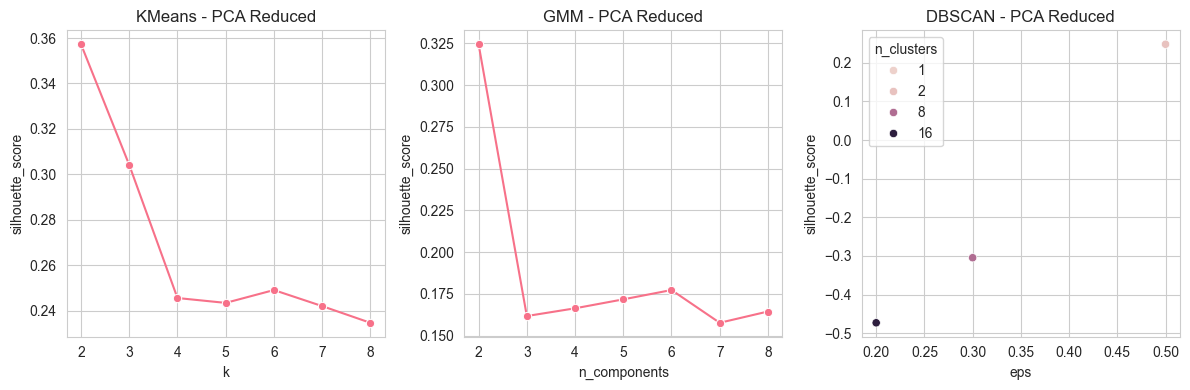

In [17]:
pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X)

print("Principal components with corresponding explained variance: ")
explained_variance_ratio = pca.explained_variance_ratio_
for indx, evr in enumerate(explained_variance_ratio):
    print(f"PC{indx+1}: {evr:.2f}")
    
    
# ===================== PCA LOADINGS / INTERPRETATION ===================== #
# z_cols contains the original feature names
feature_names = z_cols  

# Create loadings DataFrame
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=feature_names
)

print("\nPCA Loadings (Feature Contributions)")
display(loadings)


# ===================== PCA VISUAL Original Features ===================== #
import matplotlib.colors as mcolors
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, pc in enumerate(loadings.columns):
    vals = loadings[pc].sort_values()
    norm = np.abs(vals) / np.max(np.abs(vals))
    colors = [mcolors.to_rgba('red', alpha=n) if v>0 else mcolors.to_rgba('blue', alpha=n) 
              for v,n in zip(vals, norm)]
    
    vals.plot(kind='barh', ax=axes[i], color=colors)
    axes[i].set_title(f"{pc} Feature Contributions")
    axes[i].set_xlabel("")
    
plt.tight_layout()
plt.show()
       
    
    
print()
print("==="*30)
print("Running Kmeans...")
print("==="*30)

kmeans_pca_results = []
# ===================== Kmeans ========================= # 
K_RANGE = range(2,9)
for k in K_RANGE: 
    km = KMeans(n_clusters=k, random_state= 42, n_init=10)
    km_labels = km.fit_predict(X_pca)
    kmeans_pca_results.append({"model": "kmeans", 
                    "k": k, 
                    "silhouette_score": silhouette_score(X_pca, km_labels),
                    "davies_bouldin": davies_bouldin_score(X_pca, km_labels),
                    "inertia": km.inertia_})   
    
print("Run Complete. Kmeans results: \n")
kmeans_df_pca = pd.DataFrame(kmeans_pca_results)
display(kmeans_df_pca)


print("\n"+"==="*30)
print("Running Gaussian Mixtures...")
print("==="*30)

# ==================== Gaussian ======================== # 
gm_pc_results = []
N_COMPONENTS = range(2,9)
for n in N_COMPONENTS: 
    gm = GaussianMixture(n_components = n, covariance_type ='full',random_state = 42)
    gm_labels = gm.fit_predict(X_pca)
    gm_pc_results.append({"model": "gaussian_mixture", 
                    "n_components": n, 
                    "silhouette_score": silhouette_score(X_pca, gm_labels),
                    "BIC": gm.bic(X_pca),
                    "AIC": gm.aic(X_pca)})
    
print("Run Complete. Gaussian Mixtures results: \n")
gm_df_pca = pd.DataFrame(gm_pc_results)
display(gm_df_pca)




print("\n"+"==="*30)
print("Running DBSCAN...")
print("==="*30)

# ===================== DBSCAN ===+===================== # 
db_pca_results = []
EPS = [0.2, 0.3, 0.5, 0.8, 1]
for e in EPS:
    db = DBSCAN(eps=e, min_samples=20)
    db_labels = db.fit_predict(X_pca)
    real_clusters = len(set(db_labels) - {-1})   # exclude noise label
    if real_clusters >= 2:
        sil = silhouette_score(X_pca, db_labels)
        dbi = davies_bouldin_score(X_pca, db_labels)
    else:
        sil = float("nan")
        dbi = float("nan")
    db_pca_results.append({"model": "dbscan",
                    "eps": e,
                    "n_clusters": real_clusters,
                    "silhouette_score": sil,
                    "davies_bouldin": dbi})


print("Run Complete. DBSCAN results: \n")
db_df_pca = pd.DataFrame(db_pca_results)
display(db_df_pca)

print("\nComparison Plot...")

fig, axes = plt.subplots(1, 3, figsize=(12,4))

sns.lineplot(data=kmeans_df_pca, x="k", y="silhouette_score", marker="o", ax=axes[0])
sns.lineplot(data=gm_df_pca, x="n_components", y="silhouette_score", marker="o", ax=axes[1])
sns.scatterplot(data=db_df_pca, x="eps", y="silhouette_score", hue="n_clusters", sizes="n_clusters", marker="o", ax=axes[2])

axes[0].set_title("KMeans - PCA Reduced")
axes[1].set_title("GMM - PCA Reduced")
axes[2].set_title("DBSCAN - PCA Reduced")

plt.tight_layout(); plt.show()


The data are reduced to **four** principal components explaining ~90% of variance. <br>
PC1 mainly contrasts fast/active versus slow/passive movement; PC2 contrasts long, less efficient paths versus shorter, more efficient paths.<br>

On **PCA** coordinates the three diagnostics still disagree (silhouette favors smaller **k**, elbow and Davies–Bouldin favor larger **k**). We **do not** pick **k** from a single curve. The next code cell uses **k_composite = median(k_sil, k_elbow, k_db)** and **K = max(k_composite, 3)**; with votes **(2, 4, 7)** this gives **K = 4**. **GMM** and **DBSCAN** stay in the loop as baselines; the **reported clusters** come from **KMeans** on `X_pca` (`random_state=42`, `n_init=10`) for interpretability and stability.

### KMeans clustering (final fit)

The cell below fits **KMeans** on the PCA embedding `X_pca` with **K** from the composite rule above (not from silhouette alone). **Cluster names** (e.g. `Fast-Balanced-Fluid`) are **automatic**: quantile thresholds on speed, path efficiency, and pause rate **across cluster centroids**—see the printed `Cluster names` block after the fit.

Signal votes → silhouette: k=2 | elbow: k=4 | davies-bouldin: k=7
Selected k=4 (composite median=4, floor=3)


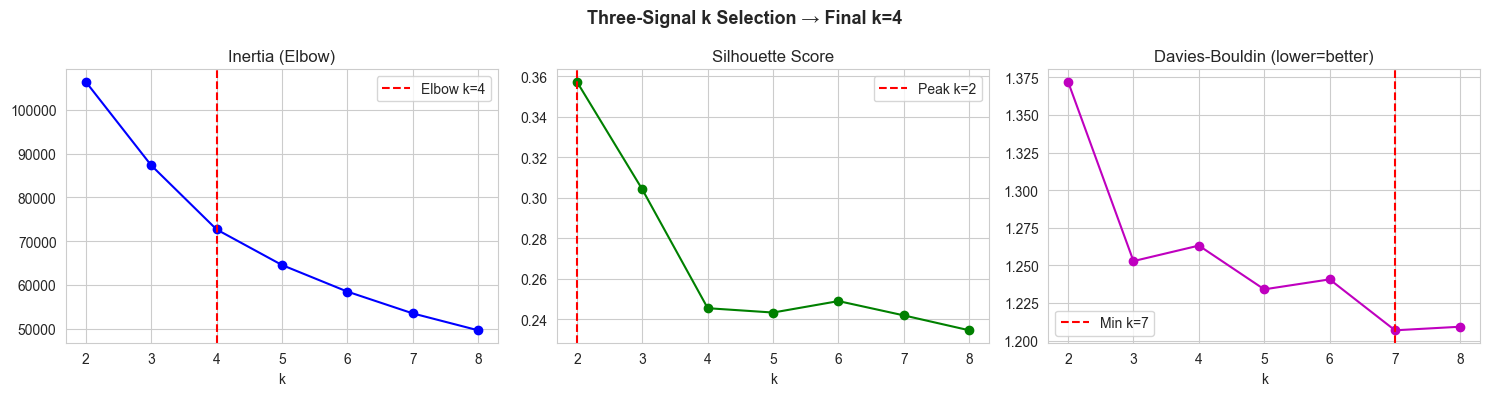


Final K-Means (k=4): silhouette=0.246, Davies-Bouldin=1.263
cluster
0    10628
1     5471
2     8686
3     1684

Cluster names:
  0: Fast-Balanced-Fluid  (n=10,628)
  1: Slow-Balanced-Fluid  (n=5,471)
  2: Moderate-Direct-Fluid  (n=8,686)
  3: Moderate-Circuitous-Hesitant  (n=1,684)


In [18]:
from kneed import KneeLocator

inertias, sil_scores, db_scores = [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))
    db_scores.append(davies_bouldin_score(X_pca, labels))

k_list = list(K_RANGE)

k_sil = k_list[int(np.argmax(sil_scores))]

knee = KneeLocator(k_list, inertias, curve="convex", direction="decreasing")
k_elbow = knee.knee if knee.knee else k_list[0]

k_db = k_list[int(np.argmin(db_scores))]

print(f"Signal votes → silhouette: k={k_sil} | elbow: k={k_elbow} | davies-bouldin: k={k_db}")

k_composite = int(np.median(sorted([k_sil, k_elbow, k_db])))
K = max(k_composite, 3)
print(f"Selected k={K} (composite median={k_composite}, floor=3)")

# Three-panel diagnostic plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_list, inertias, "b-o")
axes[0].axvline(k_elbow, color="red", linestyle="--", label=f"Elbow k={k_elbow}")
axes[0].set_title("Inertia (Elbow)"); axes[0].set_xlabel("k"); axes[0].legend()

axes[1].plot(k_list, sil_scores, "g-o")
axes[1].axvline(k_sil, color="red", linestyle="--", label=f"Peak k={k_sil}")
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k"); axes[1].legend()

axes[2].plot(k_list, db_scores, "m-o")
axes[2].axvline(k_db, color="red", linestyle="--", label=f"Min k={k_db}")
axes[2].set_title("Davies-Bouldin (lower=better)"); axes[2].set_xlabel("k"); axes[2].legend()

plt.suptitle(f"Three-Signal k Selection → Final k={K}", fontsize=13, weight="bold")
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "cluster_eval.png"), dpi=150, bbox_inches="tight")
plt.show()

# Fit final model
km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
feat_df["cluster"] = km_final.fit_predict(X_pca)

sil = silhouette_score(X_pca, feat_df["cluster"])
dbi = davies_bouldin_score(X_pca, feat_df["cluster"])
print(f"\nFinal K-Means (k={K}): silhouette={sil:.3f}, Davies-Bouldin={dbi:.3f}")
print(feat_df["cluster"].value_counts().sort_index().to_string())

# Auto-name clusters from relative quantile thresholds
cluster_profiles = feat_df.groupby("cluster")[z_cols].mean()
speed_q3 = cluster_profiles["speed_mean"].quantile(0.75)
speed_q1 = cluster_profiles["speed_mean"].quantile(0.25)
path_q3  = cluster_profiles["path_efficiency"].quantile(0.75)
path_q1  = cluster_profiles["path_efficiency"].quantile(0.25)
pause_q3 = cluster_profiles["pause_rate"].quantile(0.75)

def _name_cluster(row):
    speed  = "Fast"       if row["speed_mean"]     >= speed_q3 else ("Slow"       if row["speed_mean"]     <= speed_q1 else "Moderate")
    eff    = "Direct"     if row["path_efficiency"] >= path_q3  else ("Circuitous" if row["path_efficiency"] <= path_q1  else "Balanced")
    pauses = "Hesitant"   if row["pause_rate"]      >= pause_q3 else "Fluid"
    return f"{speed}-{eff}-{pauses}"

cluster_names = {int(cid): _name_cluster(row) for cid, row in cluster_profiles.iterrows()}
feat_df["cluster_name"] = feat_df["cluster"].map(cluster_names)
print("\nCluster names:")
for cid, name in cluster_names.items():
    n = (feat_df["cluster"] == cid).sum()
    print(f"  {cid}: {name}  (n={n:,})")


### Cluster results

The **composite rule** (median of silhouette-, elbow-, and Davies–Bouldin-optimal *k*, with floor 3) sets *K*; the plots above are the inputs to that vote, not a single “winner” curve. Final **KMeans** on `X_pca` assigns every session to exactly one cluster (no mixture posteriors, no DBSCAN noise labels). Names come from quantiles of speed, path efficiency, and pause rate over cluster centroids.


In [19]:
# Profile each cluster — mean of the 6 core features per group
profile_cols = ["speed_mean", "path_efficiency", "pause_rate", "speed_std", "duration", "path_length"]
cluster_profiles_df = (
    feat_df.groupby("cluster")[profile_cols]
    .mean()
    .round(3)
)

print("Cluster profiles (mean feature values):")
display(cluster_profiles_df)
print("\nCluster names (from K-Means cell):")
for cid, name in cluster_names.items():
    n = (feat_df["cluster"] == cid).sum()
    print(f"  Cluster {cid}: {name}  ({n:,} sessions)")

Cluster profiles (mean feature values):


,speed_mean,path_efficiency,pause_rate,speed_std,duration,path_length
cluster,,,,,,
0,1.666,0.146,0.424,4.909,9627.952,999.924
1,0.658,0.186,0.608,2.650,10930.656,867.734
2,1.494,0.266,0.453,4.435,8118.715,763.958
3,0.878,0.121,0.678,4.180,26533.804,1533.560



Cluster names (from K-Means cell):
  Cluster 0: Fast-Balanced-Fluid  (10,628 sessions)
  Cluster 1: Slow-Balanced-Fluid  (5,471 sessions)
  Cluster 2: Moderate-Direct-Fluid  (8,686 sessions)
  Cluster 3: Moderate-Circuitous-Hesitant  (1,684 sessions)


Game type distribution within each cluster (row %):


game_type,polygon-stacking,sheep-herding,thread-the-needle
cluster_name,,,
Fast-Balanced-Fluid,0.328,0.322,0.350
Moderate-Circuitous-Hesitant,0.321,0.351,0.328
Moderate-Direct-Fluid,0.323,0.330,0.346
Slow-Balanced-Fluid,0.333,0.311,0.356


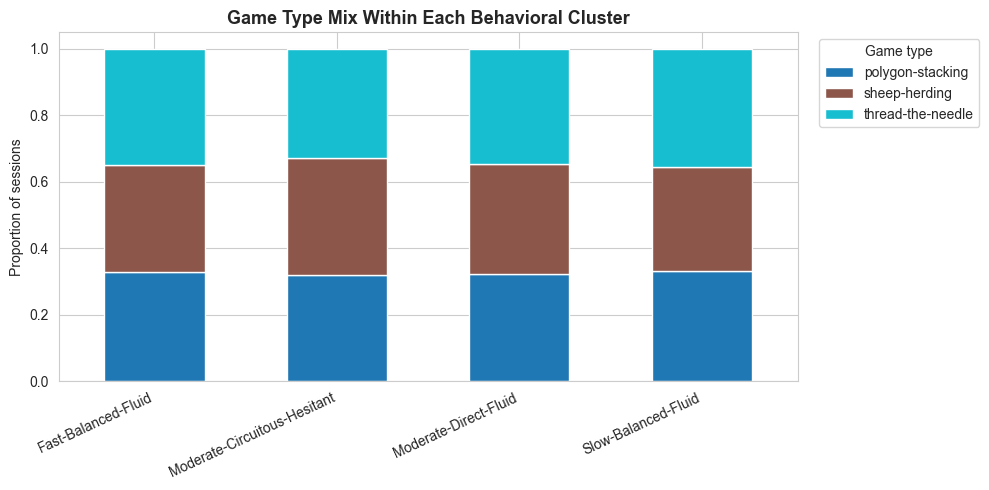


Baseline per game type (uniform): 33.3%
Max deviation from baseline per cluster:
  Fast-Balanced-Fluid: max delta=1.7%  trait-like
  Moderate-Circuitous-Hesitant: max delta=1.8%  trait-like
  Moderate-Direct-Fluid: max delta=1.3%  trait-like
  Slow-Balanced-Fluid: max delta=2.3%  trait-like


In [20]:
# ── Game type × cluster cross-tab ────────────────────────────────────────────
# Key question: is hesitant/circuitous behavior a stable personal trait,
# or is it driven by which game the user played?
# If game_type distributes ~evenly within each cluster → trait (personal)
# If one game dominates a cluster → task mechanics are driving cluster assignment

crosstab = pd.crosstab(
    feat_df["cluster_name"],
    feat_df["game_type"],
    normalize="index",   # row %: what share of each cluster played each game?
).round(3)

print("Game type distribution within each cluster (row %):")
display(crosstab)

ax = crosstab.plot(
    kind="bar", stacked=True, figsize=(10, 5),
    colormap="tab10", edgecolor="white", width=0.55,
)
ax.set_title("Game Type Mix Within Each Behavioral Cluster", fontsize=13, weight="bold")
ax.set_ylabel("Proportion of sessions")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
ax.legend(title="Game type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

# Uniform mix (~33% each) → behavior is a stable personal trait
# Strong skew to one game → task mechanics are the driver
baseline = 1 / feat_df["game_type"].nunique()
print(f"\nBaseline per game type (uniform): {baseline:.1%}")
print("Max deviation from baseline per cluster:")
for row_name, row in crosstab.iterrows():
    max_dev = (row - baseline).abs().max()
    flag = "  task-driven" if max_dev > 0.10 else "  trait-like"
    print(f"  {row_name}: max delta={max_dev:.1%}{flag}")


Cluster names (from K-Means cell):
  Cluster 0: Fast-Balanced-Fluid  (10,628 sessions)
  Cluster 1: Slow-Balanced-Fluid  (5,471 sessions)
  Cluster 2: Moderate-Direct-Fluid  (8,686 sessions)
  Cluster 3: Moderate-Circuitous-Hesitant  (1,684 sessions)



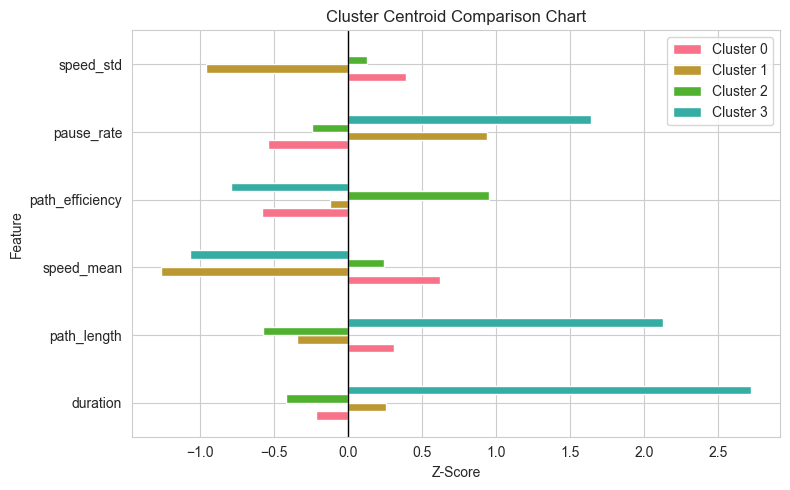

In [21]:
centroids_original = pca.inverse_transform(km_final.cluster_centers_)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=z_cols,
    index=[f"Cluster {i}" for i in range(K)]
)

print("\nCluster names (from K-Means cell):")
for cid, name in cluster_names.items():
    n = (feat_df["cluster"] == cid).sum()
    print(f"  Cluster {cid}: {name}  ({n:,} sessions)")

    
print()
centroids_df.T.plot(kind="barh", figsize=(8,5))
plt.title("Cluster Centroid Comparison Chart")
plt.xlabel("Z-Score")
plt.ylabel("Feature")
plt.axvline(0, color="black", linestyle="-", linewidth=1)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "cluster_profiles.png"), dpi=150, bbox_inches="tight")
plt.show()


The **Cluster Centroid Comparison Chart** compares **z-scored** feature means for **four** clusters. Labels are **data-driven** (see `_name_cluster` above), so do not assume “cluster 0 = baseline.” Read the **printed cluster names and bar directions**: you should see profiles such as fast/balanced/fluid, slow/balanced/fluid, moderate/circuitous/hesitant (often the **smallest** group: longer duration, lower efficiency, more pauses), and moderate/direct/fluid—aligned with the progress report. If you change `random_state` or the pipeline, **numeric cluster IDs may permute**; trust **names + centroid patterns**, not fixed ID→behavior stories.

---

PCA components 1 and 2 (computed in Step 7) serve directly as the x/y axes. Sessions that behaved similarly appear close together; sessions that behaved differently appear far apart. Each dot is colored by its K-Means cluster label.


Outlier sessions (top 2% by centroid distance): 530
               game_type                  cluster_name  anomaly_score  \
22731  thread-the-needle  Moderate-Circuitous-Hesitant         17.431   
18719  thread-the-needle  Moderate-Circuitous-Hesitant         15.917   
6082       sheep-herding  Moderate-Circuitous-Hesitant         15.046   
26173  thread-the-needle  Moderate-Circuitous-Hesitant         14.849   
26408  thread-the-needle  Moderate-Circuitous-Hesitant         13.876   
2159       sheep-herding           Fast-Balanced-Fluid         13.800   
10642      sheep-herding  Moderate-Circuitous-Hesitant         13.685   
26215      sheep-herding  Moderate-Circuitous-Hesitant         12.339   
14079  thread-the-needle  Moderate-Circuitous-Hesitant         11.564   
7249   thread-the-needle  Moderate-Circuitous-Hesitant         11.457   

       speed_mean  pause_rate  path_efficiency  
22731       0.633       0.819            0.050  
18719       1.019       0.653            0.048

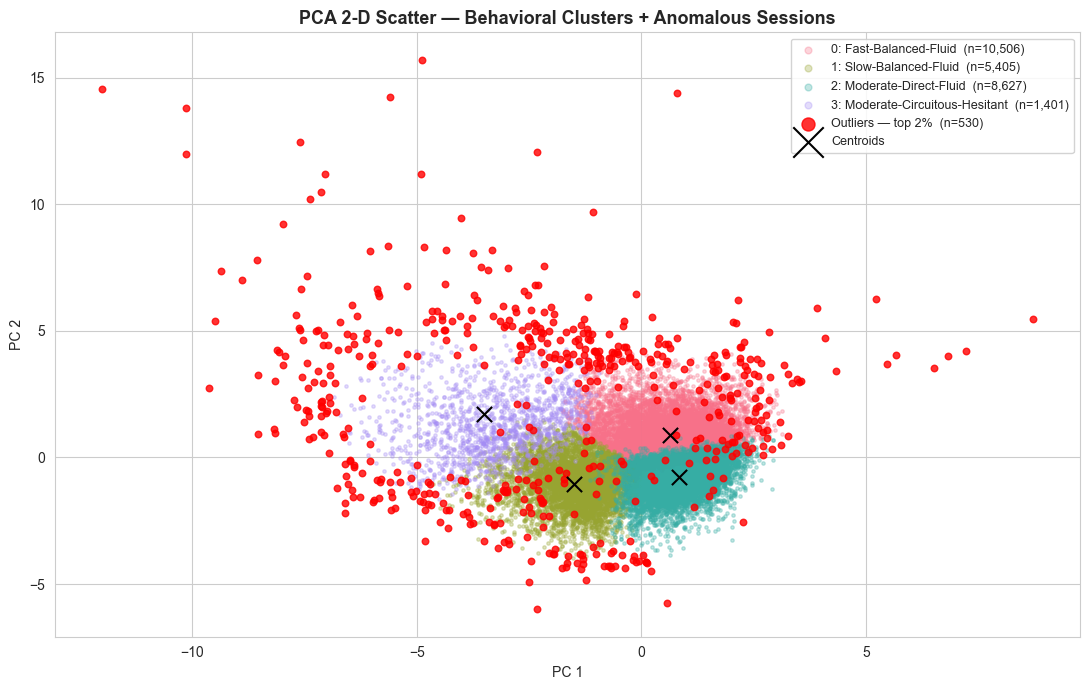

In [22]:
feat_df["pca_x"] = X_pca[:, 0]
feat_df["pca_y"] = X_pca[:, 1]

# Distance from each session's assigned centroid in PCA space.
# Large distance = atypical for its cluster = potentially suspicious for CAPTCHA.
centroid_coords = km_final.cluster_centers_[feat_df["cluster"].values]
distances = np.linalg.norm(X_pca - centroid_coords, axis=1)
feat_df["anomaly_score"] = distances
feat_df["is_outlier"] = distances > np.percentile(distances, 98)

n_out = feat_df["is_outlier"].sum()
print(f"Outlier sessions (top 2% by centroid distance): {n_out:,}")
print(feat_df[feat_df["is_outlier"]][
    ["game_type", "cluster_name", "anomaly_score", "speed_mean", "pause_rate", "path_efficiency"]
].sort_values("anomaly_score", ascending=False).head(10).round(3))

print("\nOutlier distribution by game type:")
print(feat_df[feat_df["is_outlier"]]["game_type"].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(11, 7))
palette = sns.color_palette("husl", n_colors=K)

for cid in sorted(feat_df["cluster"].unique()):
    mask = (feat_df["cluster"] == cid) & (~feat_df["is_outlier"])
    ax.scatter(
        feat_df.loc[mask, "pca_x"], feat_df.loc[mask, "pca_y"],
        c=[palette[cid]], s=6, alpha=0.3,
        label=f"{cid}: {cluster_names.get(cid, '')}  (n={mask.sum():,})",
    )

outlier_mask = feat_df["is_outlier"]
ax.scatter(
    feat_df.loc[outlier_mask, "pca_x"], feat_df.loc[outlier_mask, "pca_y"],
    c="red", s=22, alpha=0.8, zorder=5,
    label=f"Outliers — top 2%  (n={n_out:,})",
)

centroids_pca = km_final.cluster_centers_
ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c="black", s=120, marker="x", zorder=6, label="Centroids",
)

ax.set_title("PCA 2-D Scatter — Behavioral Clusters + Anomalous Sessions", fontsize=13, weight="bold")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
ax.legend(loc="best", markerscale=2, framealpha=0.85, fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "anomaly_detection.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## Step 9: Export

Write the three output files that the dashboard reads. All files go to `dashboard/data/` so re-running this notebook automatically updates the dashboard.


| File | Contents |
|---|---|
| `scatter_points.json` | One record per session: PCA x/y, cluster label, game type, and feature values for tooltips |
| `cluster_profiles.json` | Per-cluster mean of each feature, normalized 0–1 for radar charts |
| `cluster_meta.json` | Cluster id, name, size, and color hex for the frontend legend |


In [23]:
import json, os

# Write directly into dashboard/data/ so the backend serves them immediately.
# Path is relative to notebook/ directory (where this notebook runs from).
OUTPUT_DIR = os.path.join("..", "dashboard", "data")
os.makedirs(OUTPUT_DIR, exist_ok=True)

scatter = feat_df[[
    "pca_x", "pca_y", "cluster", "cluster_name",
    "game_type", "speed_mean", "path_efficiency", "pause_rate", "duration",
    "anomaly_score", "is_outlier",
]].copy()
scatter["cluster"] = scatter["cluster"].astype(int)
scatter["is_outlier"] = scatter["is_outlier"].astype(bool)
scatter.to_json(f"{OUTPUT_DIR}/scatter_points.json", orient="records", indent=2)
print(f"scatter_points.json  — {len(scatter):,} rows")


profile_cols = ["speed_mean", "path_efficiency", "pause_rate", "speed_std", "duration", "path_length"]
cluster_means = (
    feat_df.groupby(["cluster", "cluster_name"])[profile_cols]
    .mean()
    .reset_index()
)
for col in profile_cols:
    lo, hi = cluster_means[col].min(), cluster_means[col].max()
    cluster_means[f"{col}_norm"] = (cluster_means[col] - lo) / (hi - lo + 1e-9)

cluster_means["cluster"] = cluster_means["cluster"].astype(int)
cluster_means.to_json(f"{OUTPUT_DIR}/cluster_profiles.json", orient="records", indent=2)
print(f"cluster_profiles.json — {len(cluster_means)} clusters")

palette_hex = sns.color_palette("husl", n_colors=K).as_hex()
cluster_meta = [
    {
        "id": int(cid),
        "name": cluster_names.get(cid, f"Cluster {cid}"),
        "size": int((feat_df["cluster"] == cid).sum()),
        "color": palette_hex[cid],
    }
    for cid in sorted(feat_df["cluster"].unique())
]
with open(f"{OUTPUT_DIR}/cluster_meta.json", "w") as f:
    json.dump(cluster_meta, f, indent=2)
print(f"cluster_meta.json    — {len(cluster_meta)} clusters")
print(f"\nAll files written to: {os.path.abspath(OUTPUT_DIR)}/")


scatter_points.json  — 26,469 rows
cluster_profiles.json — 4 clusters
cluster_meta.json    — 4 clusters

All files written to: /Users/lukehiura/CSE6242-Captcha/dashboard/data/
